In [13]:
import pandas as pd
import numpy as np
import os
from pathlib import Path  
pd.set_option("display.max_columns", 120)
DATA = Path("DATA")


In [14]:

tickets   = pd.read_csv(DATA / "ticket_data.csv")
cities    = pd.read_csv(DATA / "cities.csv")
stations  = pd.read_csv(DATA / "stations.csv")
providers = pd.read_csv(DATA / "providers.csv")

print(" Chargement :")
print("tickets:", tickets.shape, "| cities:", cities.shape, "| stations:", stations.shape, "| providers:", providers.shape)

print("\n tickets (5):")
display(tickets.head())
print("\n cities (5):")
display(cities.head())
print("\n stations (5):")
display(stations.head())
print("\n providers (5):")
display(providers.head())


 Chargement :
tickets: (74168, 12) | cities: (8040, 6) | stations: (11035, 4) | providers: (227, 10)

 tickets (5):


,id,company,o_station,d_station,departure_ts,arrival_ts,price_in_cents,search_ts,middle_stations,other_companies,o_city,d_city
0,6795025,8385,NaN,NaN,2017-10-13 14:00:00+00,2017-10-13 20:10:00+00,4550,2017-10-01 00:13:31.327+00,NaN,NaN,611,542
1,6795026,9,63.0,1044.0,2017-10-13 13:05:00+00,2017-10-14 06:55:00+00,1450,2017-10-01 00:13:35.773+00,"{149,418}",{13},611,542
2,6795027,8377,5905.0,6495.0,2017-10-13 13:27:00+00,2017-10-14 21:24:00+00,7400,2017-10-01 00:13:40.212+00,"{798,798,6794,6246}","{8377,8376}",611,542
3,6795028,8377,5905.0,6495.0,2017-10-13 13:27:00+00,2017-10-14 11:02:00+00,13500,2017-10-01 00:13:40.213+00,"{798,798,6794,6246}","{8377,8376}",611,542
4,6795029,8381,5905.0,6495.0,2017-10-13 21:46:00+00,2017-10-14 19:32:00+00,7710,2017-10-01 00:13:40.213+00,"{5983,5983}",{8380},611,542



 cities (5):


,id,local_name,unique_name,latitude,longitude,population
0,5159,"Padua, Veneto, Italia",padua,45.406435,11.876761,209678.0
1,76,"Barcelona, Cataluña, España",barcelona,41.385064,2.173404,1611822.0
2,81,"Basel, Basel-Stadt, Schweiz",basel,47.593437,7.619812,NaN
3,259,"Erlangen, Bayern, Deutschland",erlangen,49.589674,11.011961,105412.0
4,11979,"Balș, Olt, România",balș,44.353354,24.095672,NaN



 stations (5):


,id,unique_name,latitude,longitude
0,1,Aalen (Stuttgarter Straße),48.835296,10.092956
1,2,Aéroport Bordeaux-Mérignac,44.830226,-0.700883
2,3,Aéroport CDG,49.009900,2.559310
3,4,Aéroport de Berlin-Schönefeld,52.389446,13.520345
4,5,Aéroport de Dresden,51.123604,13.764737



 providers (5):


,id,company_id,provider_id,name,fullname,has_wifi,has_plug,has_adjustable_seats,has_bicycle,transport_type
0,9,1,NaN,ouibus,Ouibus,True,True,True,False,bus
1,10,2,NaN,deinbus,Deinbus.de,False,False,False,False,bus
2,11,3,NaN,infobus,Infobus,False,False,False,False,bus
3,12,4,NaN,studentAgency,Student Agency,False,False,False,False,bus
4,13,5,NaN,flixbus,Flixbus,True,False,False,False,bus


In [15]:

# Étape 2 — Nettoyage de base
from IPython.display import display

# 2.1 Dates → datetime
for col in ["departure_ts", "arrival_ts", "search_ts"]:
    tickets[col] = pd.to_datetime(tickets[col], errors="coerce")

# 2.2 Prix en euros
tickets["price_eur"] = tickets["price_in_cents"] / 100.0

# 2.3 Contrôle des manquants
print(" Manquants (tickets) :")
display(tickets.isna().sum().to_frame("na_count").T)

print("\n Étape 2 OK — conversion datetime & prix_eur.")


 Manquants (tickets) :


,id,company,o_station,d_station,departure_ts,arrival_ts,price_in_cents,search_ts,middle_stations,other_companies,o_city,d_city,price_eur
na_count,0,0,41441,41441,0,0,0,73,41441,41441,0,0,0



 Étape 2 OK — conversion datetime & prix_eur.


In [16]:

# Étape 3 — Merge providers
expected = ["id", "provider_id", "name", "fullname", "transport_type", "has_wifi", "has_plug"]
missing = [c for c in expected if c not in providers.columns]
if missing:
    raise KeyError(f"Colonnes manquantes dans providers: {missing}")

providers_small = (
    providers[expected]
    .rename(columns={
        "id": "provider_key",                  # PK interne pour jointure
        "provider_id": "provider_external_id"  # identifiant externe éventuel
    })
    .drop_duplicates(subset="provider_key")    # évite dupliquer les lignes tickets
)

# Harmoniser les types de clé
tickets["company"] = pd.to_numeric(tickets["company"], errors="coerce")
providers_small["provider_key"] = pd.to_numeric(providers_small["provider_key"], errors="coerce")

# Merge many-to-one
tickets = tickets.merge(
    providers_small,
    left_on="company",
    right_on="provider_key",
    how="left",
    validate="m:1"   # commente si providers a des id dupliqués
).rename(columns={
    "name": "provider_name",
    "fullname": "provider_fullname",
    "transport_type": "transport_mode"
}).drop(columns=["provider_key"])  # clé technique plus utile

rate = tickets["provider_name"].notna().mean()
print(f" Providers fusionnés — providers trouvés pour {rate:.1%} des lignes")

# Contrôle rapide
display(tickets[["company","provider_name","provider_fullname","transport_mode","has_wifi","has_plug"]].head())


 Providers fusionnés — providers trouvés pour 100.0% des lignes


,company,provider_name,provider_fullname,transport_mode,has_wifi,has_plug
0,8385,bbc,Blablacar,carpooling,False,False
1,9,ouibus,Ouibus,bus,True,True
2,8377,corailintercite,Intercités,train,False,False
3,8377,corailintercite,Intercités,train,False,False
4,8381,coraillunea,Intercités de Nuit,train,False,False


In [17]:

# Étape 4 — Merge cities

# Origine
cities_origin = cities.rename(columns={
    "id": "origin_city_id",
    "local_name": "origin_city_name",
    "latitude": "origin_lat",
    "longitude": "origin_lon",
    "population": "origin_population",
})
tickets = tickets.merge(
    cities_origin[["origin_city_id", "origin_city_name", "origin_lat", "origin_lon", "origin_population"]],
    left_on="o_city", right_on="origin_city_id", how="left"
)

# Destination
cities_dest = cities.rename(columns={
    "id": "dest_city_id",
    "local_name": "dest_city_name",
    "latitude": "dest_lat",
    "longitude": "dest_lon",
    "population": "dest_population",
})
tickets = tickets.merge(
    cities_dest[["dest_city_id", "dest_city_name", "dest_lat", "dest_lon", "dest_population"]],
    left_on="d_city", right_on="dest_city_id", how="left"
)

ok_rate_cities = tickets[["origin_city_name","dest_city_name"]].notna().all(1).mean()
print(f" Cities fusionnées — paires OD complètes pour {ok_rate_cities:.1%} des lignes")

display(tickets[[
    "o_city","d_city","origin_city_name","dest_city_name",
    "origin_lat","origin_lon","dest_lat","dest_lon"
]].head())


 Cities fusionnées — paires OD complètes pour 100.0% des lignes


,o_city,d_city,origin_city_name,dest_city_name,origin_lat,origin_lon,dest_lat,dest_lon
0,611,542,"Orléans, Centre-Val de Loire, France","Montpellier, Occitanie, France",47.907018,1.90627,43.604452,3.918318
1,611,542,"Orléans, Centre-Val de Loire, France","Montpellier, Occitanie, France",47.907018,1.90627,43.604452,3.918318
2,611,542,"Orléans, Centre-Val de Loire, France","Montpellier, Occitanie, France",47.907018,1.90627,43.604452,3.918318
3,611,542,"Orléans, Centre-Val de Loire, France","Montpellier, Occitanie, France",47.907018,1.90627,43.604452,3.918318
4,611,542,"Orléans, Centre-Val de Loire, France","Montpellier, Occitanie, France",47.907018,1.90627,43.604452,3.918318


In [18]:

#  — Merge stations

# Origine
stations_origin = stations.rename(columns={
    "id": "origin_station_id",
    "unique_name": "origin_station_name",
    "latitude": "origin_station_lat",
    "longitude": "origin_station_lon",
})
tickets = tickets.merge(
    stations_origin[["origin_station_id","origin_station_name","origin_station_lat","origin_station_lon"]],
    left_on="o_station", right_on="origin_station_id", how="left"
)

# Destination
stations_dest = stations.rename(columns={
    "id": "dest_station_id",
    "unique_name": "dest_station_name",
    "latitude": "dest_station_lat",
    "longitude": "dest_station_lon",
})
tickets = tickets.merge(
    stations_dest[["dest_station_id","dest_station_name","dest_station_lat","dest_station_lon"]],
    left_on="d_station", right_on="dest_station_id", how="left"
)

print(" Stations fusionnées (NaN tolérés sur o_station/d_station)")
display(tickets[["o_station","origin_station_name","d_station","dest_station_name"]].head())


 Stations fusionnées (NaN tolérés sur o_station/d_station)


,o_station,origin_station_name,d_station,dest_station_name
0,NaN,NaN,NaN,NaN
1,63.0,Avenue Georges Pompidou,1044.0,Station Les Sabines
2,5905.0,Les Aubrais,6495.0,Montpellier
3,5905.0,Les Aubrais,6495.0,Montpellier
4,5905.0,Les Aubrais,6495.0,Montpellier


In [20]:

# Étape  — Features
import numpy as np
import pandas as pd

#  Durée & advance (en heures)
tickets["duration_hours"] = (tickets["arrival_ts"] - tickets["departure_ts"]).dt.total_seconds() / 3600.0
tickets["advance_hours"]  = (tickets["departure_ts"] - tickets["search_ts"]).dt.total_seconds() / 3600.0

# Distance Haversine (km) entre VILLES (lat/lon)
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 6371.0088 * 2 * np.arcsin(np.sqrt(a))  # km (rayon moyen de la Terre)

tickets["distance_km"] = haversine_km(
    tickets["origin_lat"], tickets["origin_lon"], tickets["dest_lat"], tickets["dest_lon"]
)

#  Buckets de distance
bins   = [-0.1, 200, 800, 2000, np.inf]
labels = ["0-200", "201-800", "801-2000", "2000+"]
tickets["distance_bucket"] = pd.cut(tickets["distance_km"], bins=bins, labels=labels)

#  Features calendaires
tickets["departure_hour"] = tickets["departure_ts"].dt.hour
tickets["departure_dow"]  = tickets["departure_ts"].dt.day_name()

print(" Features OK")
display(tickets[["price_eur","duration_hours","advance_hours","distance_km","distance_bucket","transport_mode"]].head())


 Features OK


,price_eur,duration_hours,advance_hours,distance_km,distance_bucket,transport_mode
0,45.5,6.166667,301.774631,503.197862,201-800,carpooling
1,14.5,17.833333,300.856730,503.197862,201-800,bus
2,74.0,31.950000,301.222163,503.197862,201-800,train
3,135.0,21.583333,301.222163,503.197862,201-800,train
4,77.1,21.766667,309.538830,503.197862,201-800,train


In [21]:

# Étape 7 — Filtrage logique minimal
before = len(tickets)

# Durée >= 0 (exclut inversions horaires/anomalies)
tickets = tickets[(tickets["duration_hours"].fillna(-1) >= 0)]

# Prix > 0
tickets = tickets[(tickets["price_eur"].fillna(0) > 0)]

after = len(tickets)
print(f"🧹 Filtrage: {before} → {after} lignes conservées")

# (Optionnel) contrôle rapide des bornes
print({
    "min_price": tickets["price_eur"].min(),
    "max_price": tickets["price_eur"].max(),
    "min_duration_h": tickets["duration_hours"].min(),
    "max_duration_h": tickets["duration_hours"].max(),
})


🧹 Filtrage: 74168 → 74168 lignes conservées
{'min_price': 3.0, 'max_price': 385.5, 'min_duration_h': 0.3333333333333333, 'max_duration_h': 492.85}


In [22]:

import numpy as np

df = tickets.copy()

# Seuils "métier"
DURATION_MIN = 0.25   # 15 minutes
DURATION_MAX = 72.0   # 3 jours
ADVANCE_MIN  = 0.0
ADVANCE_MAX  = 720.0  # 30 jours
DIST_MIN     = 1.0
DIST_MAX     = 3000.0

# Seuils prix via quantiles
p01 = df["price_eur"].quantile(0.01)
p99 = df["price_eur"].quantile(0.99)

before = len(df)
df = df[
    (df["duration_hours"].between(DURATION_MIN, DURATION_MAX, inclusive="both")) &
    (df["advance_hours"].between(ADVANCE_MIN, ADVANCE_MAX, inclusive="both")) &
    (df["distance_km"].between(DIST_MIN, DIST_MAX, inclusive="both")) &
    (df["price_eur"].between(p01, p99, inclusive="both"))
]
after = len(df)

print(f" Nettoyage renforcé: {before} → {after} lignes")
print({
    "price_p01": round(p01, 2),
    "price_p99": round(p99, 2),
    "duration_bounds_h": (DURATION_MIN, DURATION_MAX),
    "advance_bounds_h": (ADVANCE_MIN, ADVANCE_MAX),
    "distance_bounds_km": (DIST_MIN, DIST_MAX),
})

# (Optionnel) retirer les doublons stricts si présents
df = df.drop_duplicates(subset=[
    "company","o_city","d_city","departure_ts","arrival_ts","price_in_cents"
])
print(" Après drop_duplicates:", len(df))


 Nettoyage renforcé: 74168 → 70495 lignes
{'price_p01': 7.0, 'price_p99': 181.0, 'duration_bounds_h': (0.25, 72.0), 'advance_bounds_h': (0.0, 720.0), 'distance_bounds_km': (1.0, 3000.0)}
 Après drop_duplicates: 39736


In [23]:

kpi_price_global = df["price_eur"].agg(["min","mean","max"]).rename("global")
kpi_price_by_mode = df.groupby("transport_mode")["price_eur"] \
                      .agg(["count","min","mean","max"]) \
                      .sort_values("mean")

print(" Prix — global (nettoyé) :")
display(kpi_price_global.to_frame().T)

print("\n Prix — par mode (nettoyé) :")
display(kpi_price_by_mode)


 Prix — global (nettoyé) :


,min,mean,max
global,7.0,44.260073,181.0



 Prix — par mode (nettoyé) :


,count,min,mean,max
transport_mode,,,,
carpooling,20604,7.0,28.687658,161.5
bus,7710,8.5,36.512099,179.8
train,11422,7.0,77.580940,181.0


In [24]:

kpi_duration_by_od = (
    df
    .groupby(["origin_city_name","dest_city_name"])
    .agg(
        n=("id","count"),
        distance_km=("distance_km","median"),
        duration_min=("duration_hours","min"),
        duration_mean=("duration_hours","mean"),
        duration_max=("duration_hours","max"),
        price_mean=("price_eur","mean"),
    )
    .reset_index()
    .sort_values(["n","duration_mean"], ascending=[False, True])
)

print(" Durées par trajet — top 10 par volume (nettoyé) :")
display(kpi_duration_by_od.head(10))


 Durées par trajet — top 10 par volume (nettoyé) :


,origin_city_name,dest_city_name,n,distance_km,duration_min,duration_mean,duration_max,price_mean
938,"Paris, Île-de-France, France","Lyon, Auvergne-Rhône-Alpes, France",1504,390.628803,3.000000,5.712555,28.516667,40.801197
614,"Lyon, Auvergne-Rhône-Alpes, France","Paris, Île-de-France, France",1482,390.628803,2.150000,6.251316,41.550000,46.203171
926,"Paris, Île-de-France, France","Lille, Hauts-de-France, France",1101,205.842875,1.133333,4.287617,37.333333,21.242779
961,"Paris, Île-de-France, France","Nantes, Pays-de-la-Loire, France",1082,338.320602,2.266667,5.129498,40.400000,37.267006
864,"Paris, Île-de-France, France","Bordeaux, Nouvelle-Aquitaine, France",762,498.668411,2.533333,7.039436,40.333333,46.595407
842,"Paris, Île-de-France, France","Amsterdam, Noord-Holland, Nederland",685,430.974323,3.683333,7.838783,36.666667,95.744672
760,"Nantes, Pays-de-la-Loire, France","Paris, Île-de-France, France",650,338.320602,2.733333,5.909487,40.100000,34.760154
976,"Paris, Île-de-France, France","Rennes, Bretagne, France",533,308.159850,2.050000,4.814728,31.333333,31.676173
875,"Paris, Île-de-France, France","Bruxelles, Bruxelles-Capitale, Belgique",529,262.652453,1.816667,3.903907,37.833333,34.046314
944,"Paris, Île-de-France, France","Marseille, Provence-Alpes-Côte d'Azur, France",511,659.558616,3.416667,8.355708,30.750000,84.383366


In [25]:

by_bucket_mode = (
    df.dropna(subset=["distance_bucket","transport_mode"])
      .groupby(["distance_bucket","transport_mode"])
      .agg(
          n=("id","count"),
          price_mean=("price_eur","mean"),
          duration_mean=("duration_hours","mean")
      )
      .reset_index()
      .sort_values(["distance_bucket","price_mean"])
)

print("📦 KPIs par tranche de distance et mode (nettoyé) :")
display(by_bucket_mode)


📦 KPIs par tranche de distance et mode (nettoyé) :


,distance_bucket,transport_mode,n,price_mean,duration_mean
1,0-200,carpooling,4806,12.582085,2.058885
0,0-200,bus,859,22.003795,9.528269
2,0-200,train,1964,33.078106,4.415479
4,201-800,carpooling,15695,33.249634,4.916523
3,201-800,bus,6191,34.967577,14.542960
5,201-800,train,9267,85.987655,8.038709
6,801-2000,bus,660,69.882955,24.851641
7,801-2000,carpooling,103,85.029126,12.941748
8,801-2000,train,191,127.311518,12.442234
9,2000+,bus,0,NaN,NaN


Matplotlib is building the font cache; this may take a moment.


💾 Figure: DATA/figures/distribution_prix_clean.png


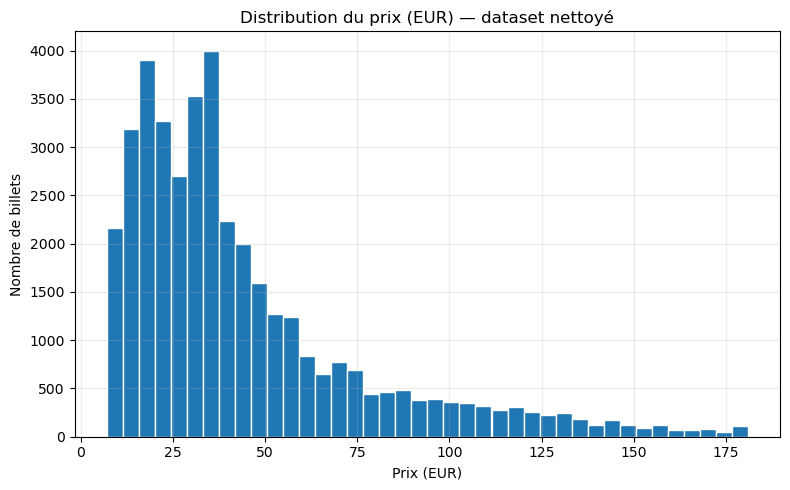

💾 Figure: DATA/figures/prix_vs_advance_clean.png


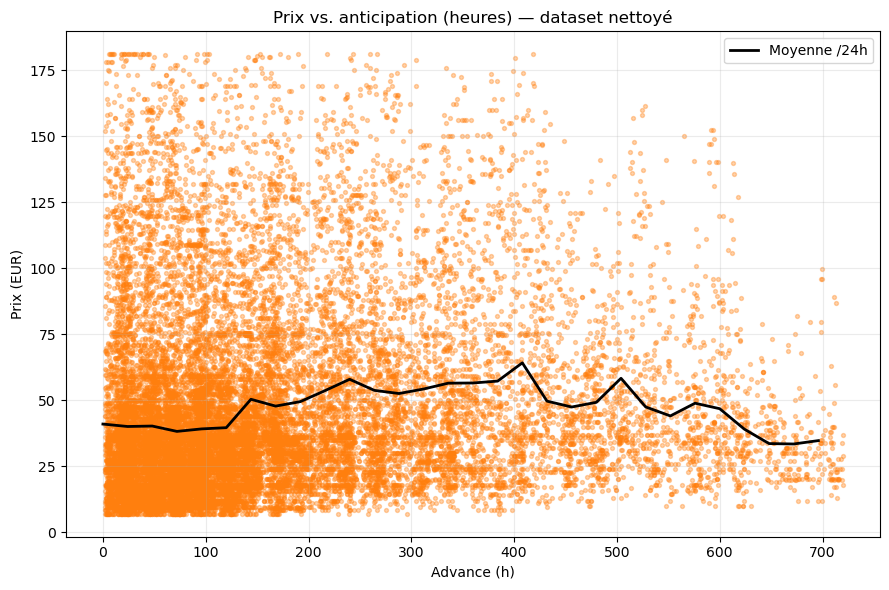

💾 Figure: DATA/figures/duree_par_mode_clean.png


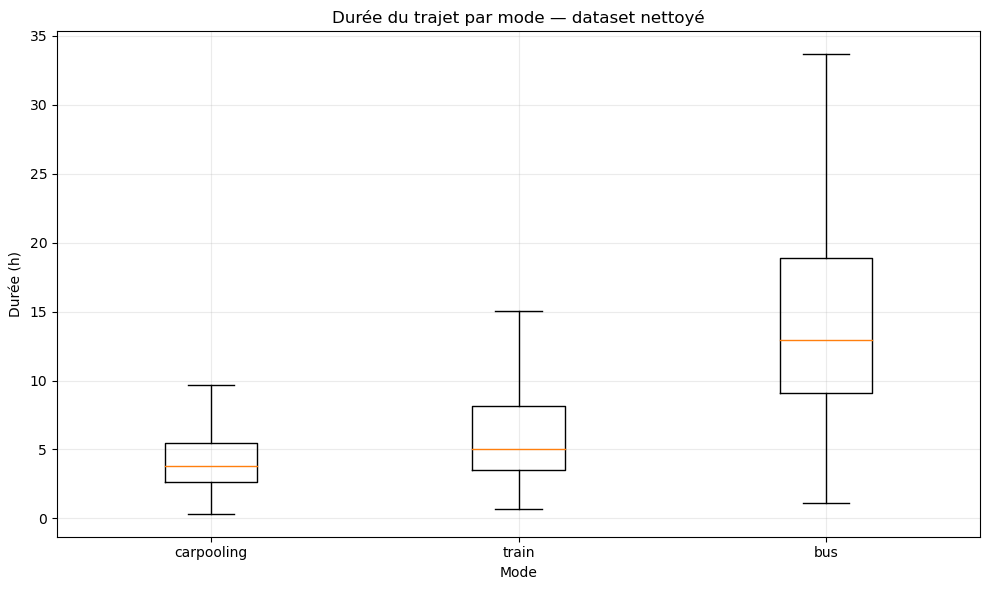

💾 Figure: DATA/figures/prix_moyen_par_bucket_mode_clean.png


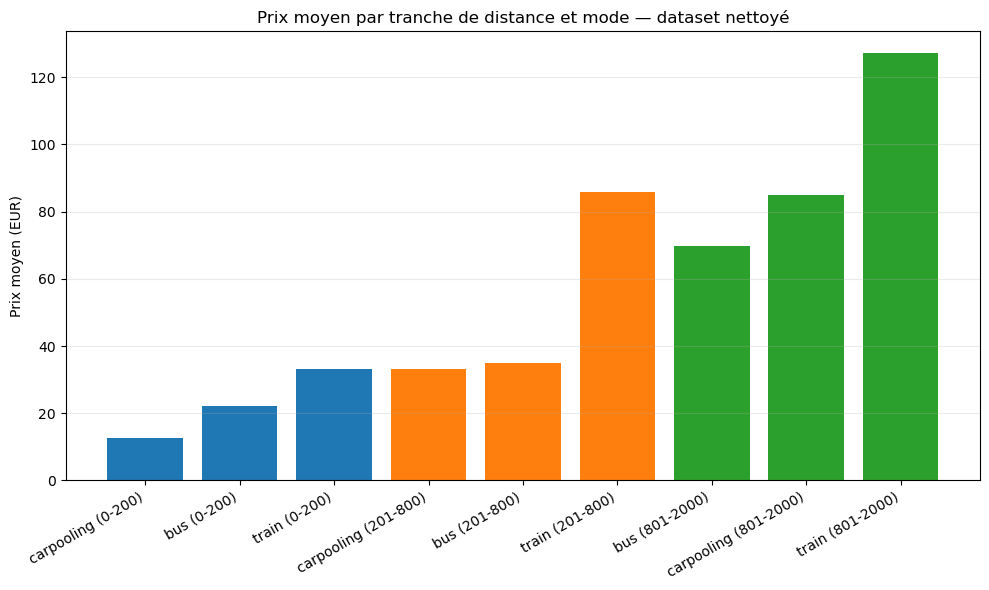

💾 Figure: DATA/figures/heatmap_top20_OD_clean.png


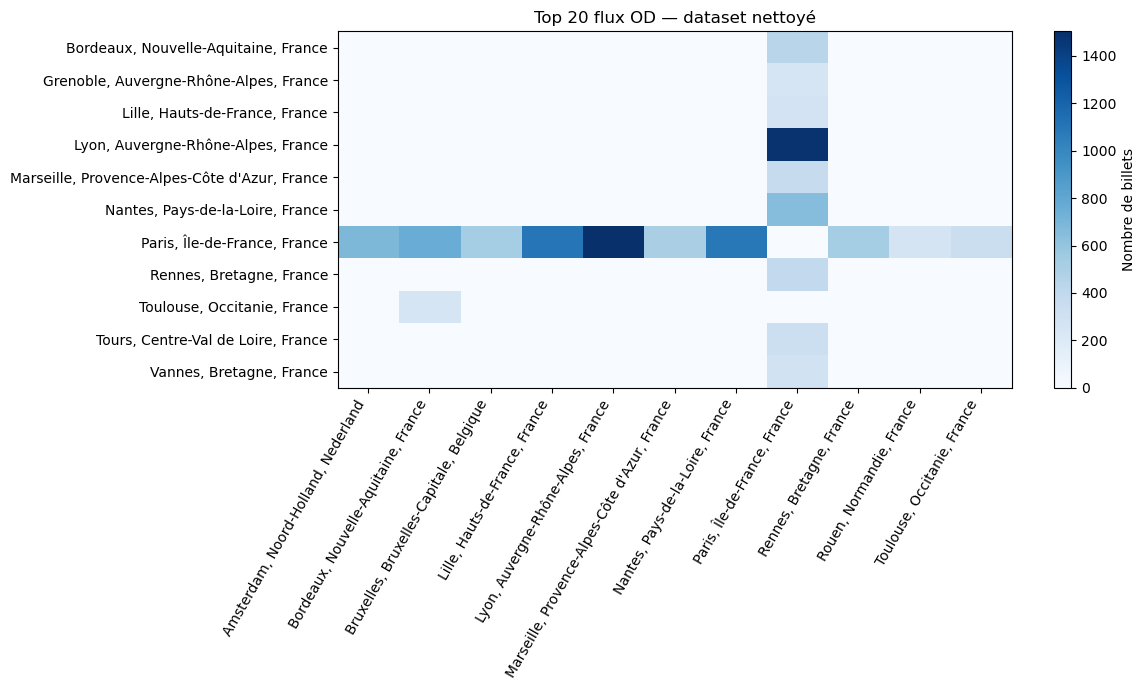

In [26]:

import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("DATA/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str):
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, dpi=160)
    print(" Figure:", (FIG_DIR / name))

# A) Distribution des prix (cap p99 déjà intégré via df)
plt.figure(figsize=(8,5))
prices = df["price_eur"].dropna()
plt.hist(prices, bins=40, color="#1f77b4", edgecolor="white")
plt.title("Distribution du prix (EUR) — dataset nettoyé")
plt.xlabel("Prix (EUR)"); plt.ylabel("Nombre de billets"); plt.grid(alpha=0.25)
save_fig("distribution_prix_clean.png"); plt.show()

# B) Prix vs Advance (+ moyenne / 24h)
plt.figure(figsize=(9,6))
sample = df[["price_eur","advance_hours"]].dropna()
if len(sample) > 25000:
    sample = sample.sample(25000, random_state=42)
plt.scatter(sample["advance_hours"], sample["price_eur"], s=8, alpha=0.35, color="#ff7f0e")
plt.title("Prix vs. anticipation (heures) — dataset nettoyé")
plt.xlabel("Advance (h)"); plt.ylabel("Prix (EUR)"); plt.grid(alpha=0.25)

bin_w = 24
bins = (sample["advance_hours"] // bin_w) * bin_w
avg = sample.groupby(bins)["price_eur"].mean().reset_index().rename(columns={"advance_hours":"bin"})
plt.plot(avg["bin"], avg["price_eur"], color="black", lw=2, label="Moyenne /24h")
plt.legend()
save_fig("prix_vs_advance_clean.png"); plt.show()

# C) Durée par mode (boxplot)
if "transport_mode" in df.columns:
    plt.figure(figsize=(10,6))
    dfb = df[["transport_mode","duration_hours"]].dropna()
    order = dfb.groupby("transport_mode")["duration_hours"].median().sort_values().index.tolist()
    data = [dfb[dfb["transport_mode"]==m]["duration_hours"].values for m in order]
    plt.boxplot(data, labels=order, showfliers=False)
    plt.title("Durée du trajet par mode — dataset nettoyé")
    plt.xlabel("Mode"); plt.ylabel("Durée (h)"); plt.grid(alpha=0.25)
    save_fig("duree_par_mode_clean.png"); plt.show()

# D) Bar — Prix moyen par tranche de distance & mode
plt.figure(figsize=(10,6))
bb = by_bucket_mode.dropna(subset=["distance_bucket"])
for bucket in bb["distance_bucket"].unique():
    sub = bb[bb["distance_bucket"]==bucket]
    plt.bar(sub["transport_mode"]+" ("+bucket+")", sub["price_mean"], label=str(bucket))
plt.title("Prix moyen par tranche de distance et mode — dataset nettoyé")
plt.ylabel("Prix moyen (EUR)"); plt.xticks(rotation=30, ha="right"); plt.grid(axis="y", alpha=0.25)
save_fig("prix_moyen_par_bucket_mode_clean.png"); plt.show()

# E) Heatmap OD (Top 20 flux)
od = (df.dropna(subset=["origin_city_name","dest_city_name"])
        .groupby(["origin_city_name","dest_city_name"])
        .size().reset_index(name="count"))
top20 = od.sort_values("count", ascending=False).head(20)
if not top20.empty:
    pivot = top20.pivot(index="origin_city_name", columns="dest_city_name", values="count").fillna(0)
    plt.figure(figsize=(12,7))
    plt.imshow(pivot.values, aspect="auto", cmap="Blues")
    plt.colorbar(label="Nombre de billets")
    plt.title("Top 20 flux OD — dataset nettoyé")
    plt.xticks(range(pivot.shape[1]), pivot.columns, rotation=60, ha="right")
    plt.yticks(range(pivot.shape[0]), pivot.index)
    plt.grid(False)
    save_fig("heatmap_top20_OD_clean.png"); plt.show()


In [27]:

OUT = Path("DATA")
df.to_csv(OUT / "tickets_clean.csv", index=False)
kpi_duration_by_od.to_csv(OUT / "kpi_duration_by_od.csv", index=False)
by_bucket_mode.to_csv(OUT / "kpi_by_distance_bucket_mode.csv", index=False)

print(" Exports :", [
    "DATA/tickets_clean.csv",
    "DATA/kpi_duration_by_od.csv",
    "DATA/kpi_by_distance_bucket_mode.csv"
])


 Exports : ['DATA/tickets_clean.csv', 'DATA/kpi_duration_by_od.csv', 'DATA/kpi_by_distance_bucket_mode.csv']


In [28]:

df["departure_dow"] = df["departure_ts"].dt.day_name()
by_dow_mode = df.groupby(["departure_dow","transport_mode"]) \
                .agg(price_mean=("price_eur","mean"),
                     duration_mean=("duration_hours","mean"),
                     n=("id","count")) \
                .reset_index()
display(by_dow_mode.sort_values(["departure_dow","price_mean"]))


,departure_dow,transport_mode,price_mean,duration_mean,n
1,Friday,carpooling,28.982038,4.367688,10411
0,Friday,bus,39.588362,15.944177,2802
2,Friday,train,82.967212,7.592844,3852
4,Monday,carpooling,26.738545,3.989118,1746
3,Monday,bus,32.666316,13.835746,760
5,Monday,train,71.674834,6.884849,1506
7,Saturday,carpooling,30.623789,4.560132,2270
6,Saturday,bus,36.592686,14.098655,1437
8,Saturday,train,76.704507,7.867822,1775
10,Sunday,carpooling,27.614716,4.018588,3452
